https://photutils.readthedocs.io/en/stable/user_guide/background.html

- Estimating the backgrond noise
- important for determining source detection significance and estimating photometric errors
- Not one single method that is always applicable
- Photutils provide tools for estimation, but it requires tweaking

### Simple Statistics
If the background level and noise are relatively constant across an image, the simplest way to estimate these values is to derive scalar quantities using simple approximations. When computing the image statistics one must take into account the astronomical sources present in the images, which add a positive tail to the distribution of pixel intensities. For example, one may consider using the image median as the background level and the image standard deviation as the 1-sigma background noise, but the resulting values are biased by the presence of real sources.

A slightly better method involves using statistics that are robust against the presence of outliers, such as the biweight location for the background level and biweight scale or normalized median absolute deviation (MAD) for the background noise estimation. However, for most astronomical scenes these methods will also be biased by the presence of astronomical sources in the image.

As an example, we load a synthetic image comprised of 100 sources with a Gaussian-distributed background whose mean is 5 and standard deviation is 2:

In [2]:
from photutils.datasets import make_100gaussians_image
data = make_100gaussians_image()

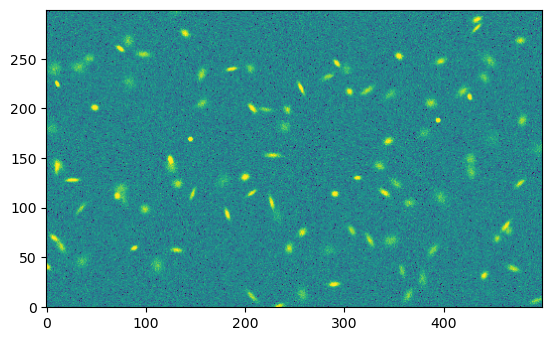

In [3]:
# Plot the image
import matplotlib.pyplot as plt
from astropy.visualization import simple_norm
norm = simple_norm(data, 'sqrt', percent=99.5)
fig, ax = plt.subplots()
ax.imshow(data, norm=norm, origin='lower')

The image median and biweight location are both larger than the true background level of 5:

In [4]:
import numpy as np
from astropy.stats import biweight_location
print(np.median(data))
print(biweight_location(data))

5.222396450477202
5.187556943476142


Similarly, using the median absolute deviation to estimate the background noise level gives a value that is larger than the true value of 2:

In [5]:
from astropy.stats import mad_std
print(mad_std(data))

2.1497096320053166
